In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/Codes/cats_and_dogs_filtered.zip"

Archive:  /content/drive/MyDrive/Codes/cats_and_dogs_filtered.zip
   creating: cats_and_dogs_filtered/
  inflating: cats_and_dogs_filtered/.DS_Store  
   creating: cats_and_dogs_filtered/test/
   creating: cats_and_dogs_filtered/train/
   creating: cats_and_dogs_filtered/test/dogs/
   creating: cats_and_dogs_filtered/test/cats/
  inflating: cats_and_dogs_filtered/test/.DS_Store  
   creating: cats_and_dogs_filtered/train/dogs/
   creating: cats_and_dogs_filtered/train/cats/
  inflating: cats_and_dogs_filtered/train/.DS_Store  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2448.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2460.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2461.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2449.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2463.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2462.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2466.jpg  
  inflating: cats_and_dogs_filtered/test

In [4]:
root_dir = r"/content/cats_and_dogs_filtered"

In [5]:
BATCH_SIZE  = 64
EPOCHS = 80
input_img_size = (128,128)
input_shape = (128,128,3)

dropout_rate = 0.3
initial_lr = 1e-3

In [6]:
tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


train_ds = tf_generator.flow_from_directory(
    root_dir+"/train",
    target_size=input_img_size,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_ds = tf_generator.flow_from_directory(
    root_dir+"/test",
    target_size=input_img_size,
    batch_size=BATCH_SIZE,
    class_mode= 'categorical'
)

Found 2752 images belonging to 2 classes.
Found 248 images belonging to 2 classes.


[1. 0.]


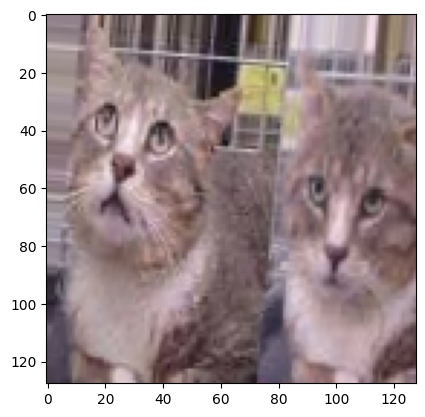

In [7]:
import matplotlib.pyplot as plt
for img,label in train_ds:
    test_img = img
    test_label = label
    break

print(test_label[0])
plt.imshow(test_img[0])

In [8]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D,BatchNormalization,Dropout,Input

model = Sequential([
    Input(shape=input_shape),
    Conv2D(64, (3, 3), activation='relu', padding='same'),  # 1. Conv2D
    Conv2D(64, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu',padding='same'),
    Conv2D(128, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),


    Conv2D(256, (3, 3), activation='relu',padding='same'),
    Conv2D(256, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),


    Conv2D(512, (3, 3), activation='relu',padding='same'),
    Conv2D(512, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dropout(dropout_rate),

    Dense(256, activation='relu'),
    Dropout(dropout_rate),


    Dense(128, activation='relu'),

    Dense(2, activation='softmax')

])

In [9]:
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',
              optimizer = Adam(learning_rate=initial_lr),
              metrics = ['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,111,234 (50.02 MB)

 Trainable params: 13,109,314 (50.01 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 74s 924ms/step - accuracy: 0.5456 - loss: 1.5672 - val_accuracy: 0.4637 - val_loss: 3.4289
Epoch 2/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 429ms/step - accuracy: 0.5554 - loss: 1.1112 - val_accuracy: 0.4597 - val_loss: 3.2416
Epoch 3/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.5365 - loss: 0.8873 - val_accuracy: 0.5363 - val_loss: 2.5565
Epoch 4/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - accuracy: 0.6062 - loss: 0.6987 - val_accuracy: 0.5081 - val_loss: 1.0118
Epoch 5/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 412ms/step - accuracy: 0.5952 - loss: 0.6874 - val_accuracy: 0.5081 - val_loss: 0.7316
Epoch 6/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 466ms/step - accuracy: 0.5684 - loss: 0.6936 - val_accuracy: 0.4758 - val_loss: 0.9294
Epoch 7/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 421ms/step - accuracy: 0.5703 - loss: 0.7011 - val_accuracy: 0.5565 - val_loss: 0.6880
Epoch 8/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.5849 - loss: 0.6790 - val_accu

In [13]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - accuracy: 0.7806 - loss: 0.7105
Validation Loss: 0.6392
Validation Accuracy: 0.7782


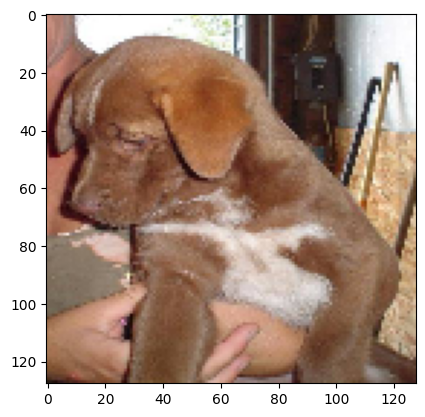

In [80]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"/content/cats_and_dogs_filtered/test/dogs/dog.2406.jpg"

img = image.load_img(img_path, target_size=input_img_size)
img_array = image.img_to_array(img)  # shape: (_, _, 3)
img_array = img_array / 255.0        # normalize

img_array = np.expand_dims(img_array, axis=0)  # shape: (1, _, _, 3)
plt.imshow(img_array[0])  # Display the image

In [85]:
class_indices = train_ds.class_indices
print(class_indices)

prediction = model.predict(img_array)[0]

# Get the class names from the class_indices dictionary
class_names = list(class_indices.keys())

# Determine the predicted class based on the highest probability
predicted_class_index = np.argmax(prediction)
predict_class = class_names[predicted_class_index]

print(f"Predicted class: {predict_class} with confidence {prediction[predicted_class_index]:.4f}")

{'cats': 0, 'dogs': 1}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: dogs with confidence 0.5212


### Model Saving

In [76]:
model.save(f'./binary_classification/ML004_Thant_Htet_Oo_model.h5')

In [77]:
import json
# Save class names to a text file
with open(f'./binary_classification/ML004_Thant_Htet_Oo_class_indices.json', 'w') as f:
    json.dump(class_indices, f)
